In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Środowisko działa")

Środowisko działa


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

parquet_files = list(DATA_RAW.glob("*.parquet"))

print(f"Liczba plików parquet: {len(parquet_files)}")
for f in parquet_files:
    print(f.name)

print(Path.cwd())
list(DATA_RAW.iterdir())

Liczba plików parquet: 0
c:\Users\karol\Desktop\esp_industrial_ml\notebooks


[WindowsPath('c:/Users/karol/Desktop/esp_industrial_ml/data/raw/dane_surowe_zipy')]

In [4]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Interim files:")
for f in DATA_INTERIM.glob("*.parquet"):
    print(f.name)

print("\nProcessed files:")
for f in DATA_PROCESSED.glob("*.parquet"):
    print(f.name)

Interim files:
all_merged_raw.parquet

Processed files:
dataset_clean.parquet


In [5]:
processed_files = list(DATA_PROCESSED.glob("*.parquet"))

df = pd.read_parquet(processed_files[0])

print(df.shape)
df.head()

(217781, 77)


,008A00444,008A00936,008A00910,008A00911,008A00720,008A00728,008A02273,008A02274,008A02275,008A00719,...,008A02280,008B05112,008A02286,008A02281,008B05115,008A02287,008B05096,008B05121,008B05126,008B05117
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-06-30 00:00:00,186.0,32.500000,68282.0,73877.0,124.0,126.0,14.0,12.1,11.2,-0.63,...,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:10,186.0,31.700001,68103.0,73804.0,124.0,126.0,14.0,12.1,11.2,-0.63,...,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:20,186.0,32.000000,68766.0,73499.0,124.0,126.0,14.0,12.1,11.3,-0.63,...,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:30,186.0,31.799999,68103.0,73645.0,124.0,126.0,13.8,11.8,11.2,-0.63,...,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:40,186.0,32.400002,68209.0,73645.0,125.0,126.0,14.0,11.9,11.2,-0.63,...,49.0,1.0,37.0,87.0,0.0,32.0,1.0,1.0,1.0,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 217781 entries, 2025-06-30 00:00:00 to 2025-08-01 00:00:00
Data columns (total 77 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   008A00444    217781 non-null  float64
 1   008A00936    217781 non-null  float64
 2   008A00910    217781 non-null  float64
 3   008A00911    217781 non-null  float64
 4   008A00720    217781 non-null  float64
 5   008A00728    217781 non-null  float64
 6   008A02273    217781 non-null  float64
 7   008A02274    217781 non-null  float64
 8   008A02275    217781 non-null  float64
 9   008A00719    217781 non-null  float64
 10  008A00727    217781 non-null  float64
 11  008A01350    217781 non-null  float64
 12  008A01341    217781 non-null  float64
 13  008A01343    217781 non-null  float64
 14  008A01347    217781 non-null  float64
 15  008A01345    217781 non-null  float64
 16  008A02118    217781 non-null  float64
 17  016A00219    210644 non-null  flo

In [7]:
df.isna().sum().sort_values(ascending=False).head(20)

016A00396    7137
016A00219    7137
008B05103       2
008B05100       2
008B05146       2
008B05167       2
008B05155       2
008B01484       2
008B01489       2
008B01474       2
008B01479       2
008B05140       2
008B05131       2
008B05139       2
008B05112       2
008B05154       2
008B05117       2
008B05096       2
008B05121       2
008B05126       2
dtype: int64

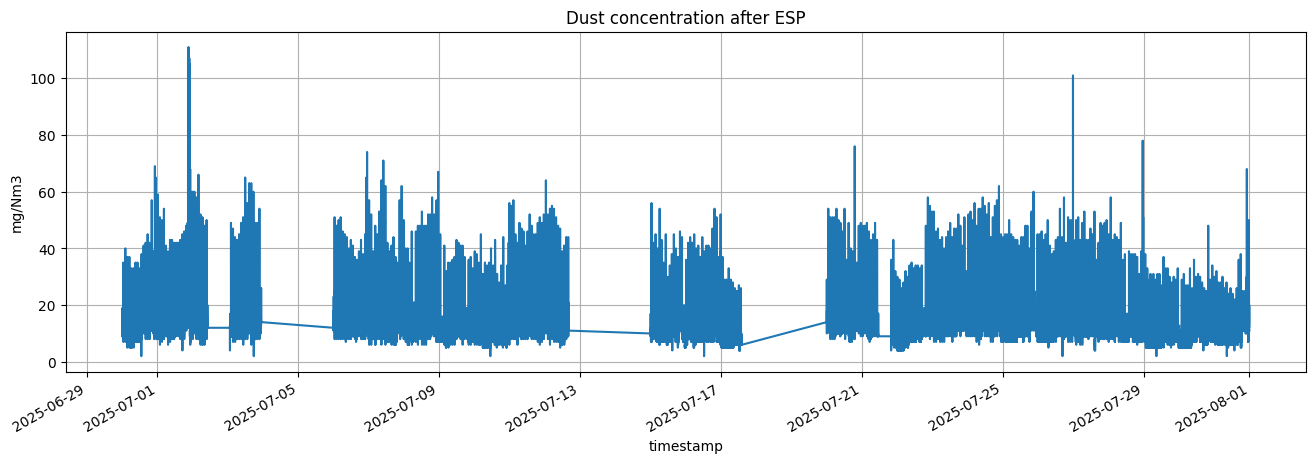

In [8]:
plt.figure(figsize=(16,5))

df['008A01345'].plot()

plt.title('Dust concentration after ESP')
plt.ylabel('mg/Nm3')
plt.grid(True)

plt.show()

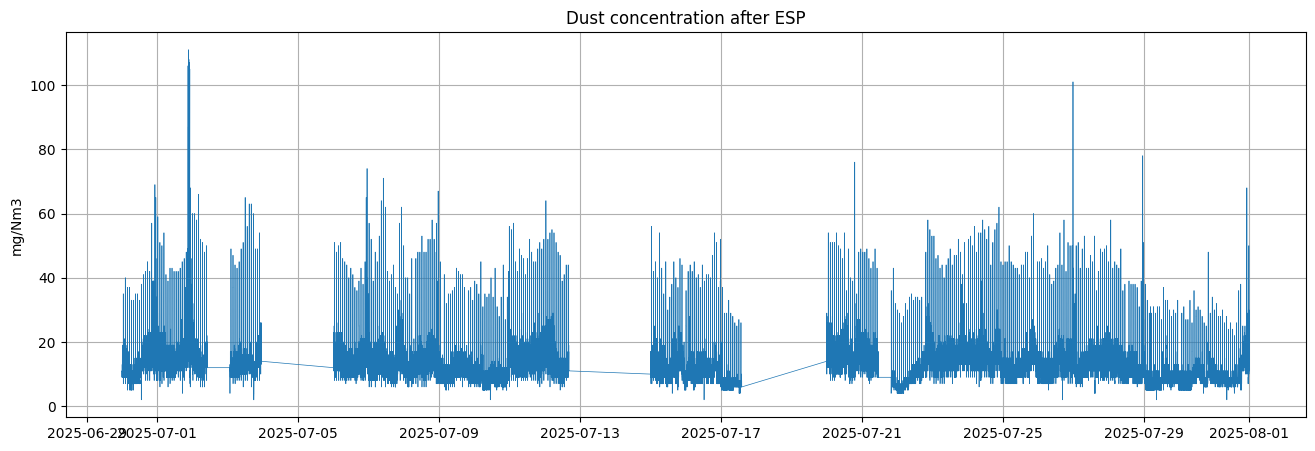

In [9]:
plt.figure(figsize=(16,5))

plt.plot(df.index, df['008A01345'], linewidth=0.5)

plt.title('Dust concentration after ESP')
plt.ylabel('mg/Nm3')
plt.grid(True)

plt.show()

In [10]:
df['008A01345'].describe()

count    217781.000000
mean         11.296082
std           5.105914
min           2.000000
25%           9.000000
50%          11.000000
75%          13.000000
max         111.000000
Name: 008A01345, dtype: float64

Histogram dystrybucji targetu

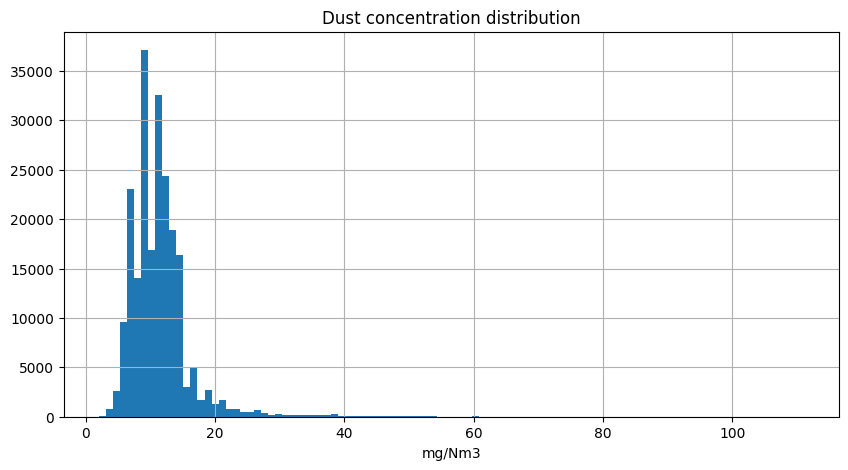

In [11]:
plt.figure(figsize=(10,5))

df['008A01345'].hist(bins=100)

plt.title('Dust concentration distribution')
plt.xlabel('mg/Nm3')

plt.show()

Korelacje z targetem

In [14]:
correlations = df.corr(numeric_only=True)['008A01345'].sort_values(ascending=False)

correlations.head(20)

008A01345    1.000000
016A00219    0.347130
008A00723    0.330279
008A00731    0.325690
016A00396    0.324820
008A00911    0.309260
008A00910    0.308169
008A02269    0.298839
008A00936    0.294513
008A02272    0.286378
008A02275    0.279084
008A02268    0.267222
008A02289    0.266142
008A02271    0.261990
008A02274    0.257327
008A02290    0.255587
008A02276    0.250535
008A02291    0.241230
008A02270    0.230884
008A02273    0.218376
Name: 008A01345, dtype: float64

In [13]:
correlations.tail(20)

008A01341   -0.082550
008B05109   -0.083912
008A02292   -0.084329
008A01347   -0.085729
008A02294   -0.085860
008A02293   -0.100097
008B05103   -0.157407
008A00727   -0.395333
008A00719   -0.404886
008B01489         NaN
008B05167         NaN
008B05155         NaN
008B05140         NaN
008B05173         NaN
008B05178         NaN
008A02266         NaN
008B05096         NaN
008B05121         NaN
008B05126         NaN
008B05117         NaN
Name: 008A01345, dtype: float64

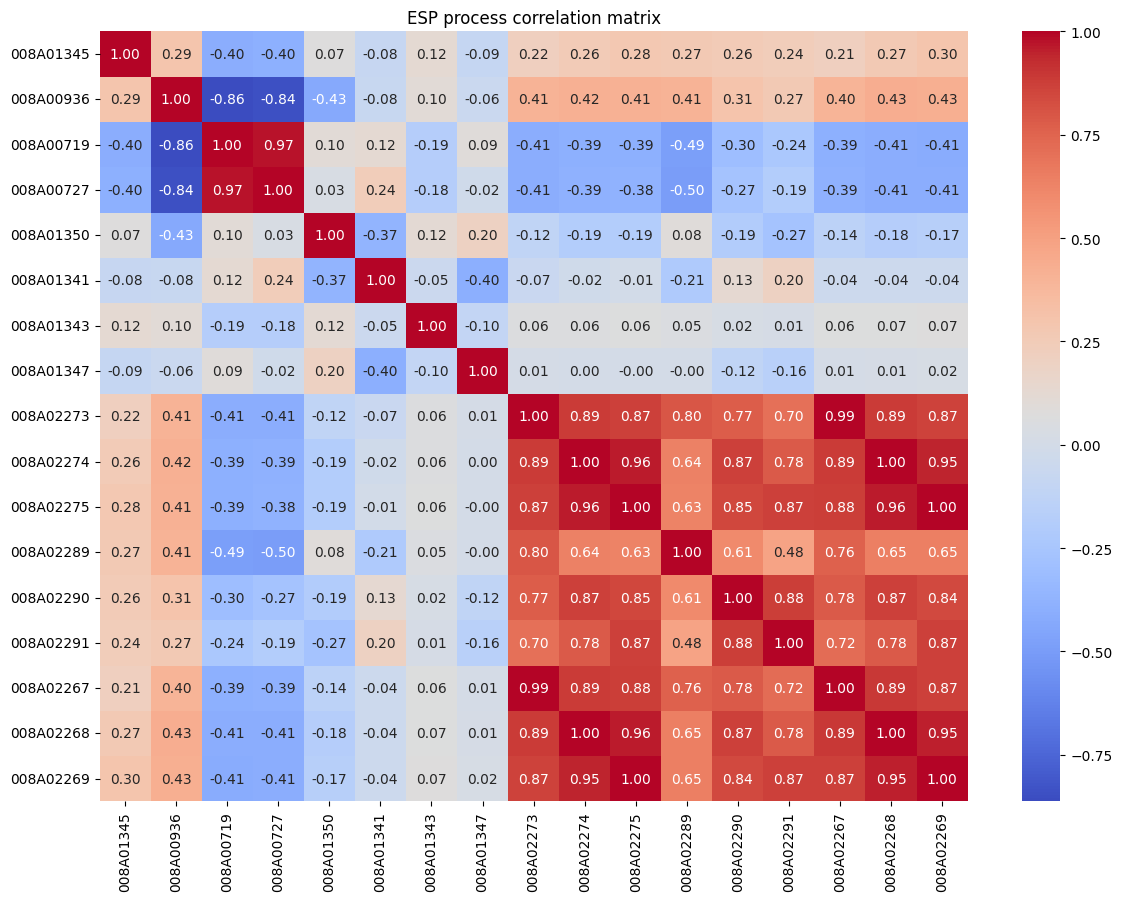

In [16]:
import seaborn as sns
selected_cols = [
    '008A01345',  # pył

    '008A00936',  # moc generatora

    '008A00719',
    '008A00727',  # ciśnienia

    '008A01350',  # O2
    '008A01341',  # SO2
    '008A01343',  # NOx
    '008A01347',  # CO

    '008A02273',
    '008A02274',
    '008A02275',  # moce ESP

    '008A02289',
    '008A02290',
    '008A02291',  # napięcia wtórne

    '008A02267',
    '008A02268',
    '008A02269',  # prądy wtórne
]

corr_matrix = df[selected_cols].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('ESP process correlation matrix')

plt.show()

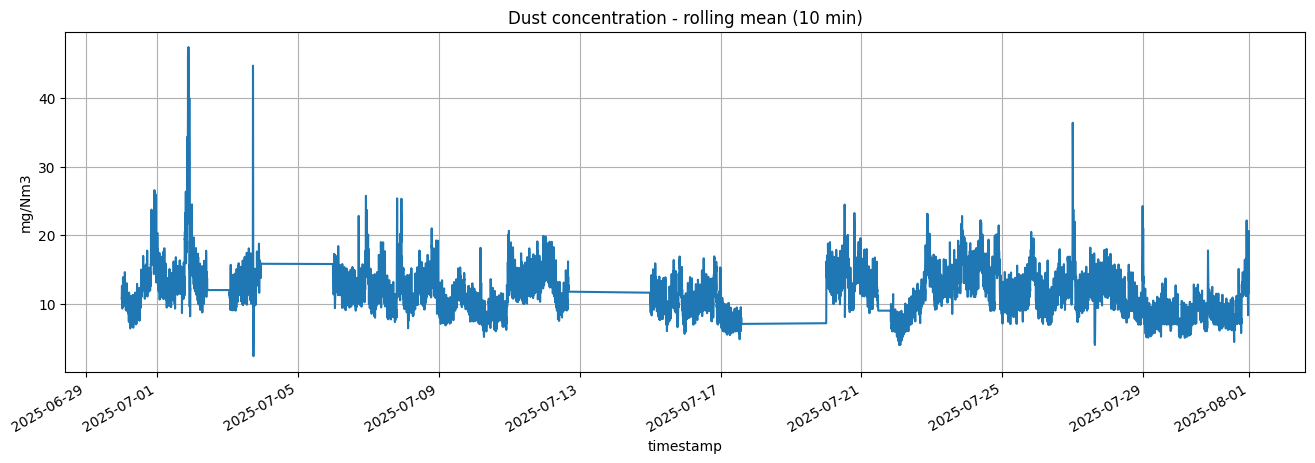

In [17]:
plt.figure(figsize=(16,5))

df['008A01345'].rolling(60).mean().plot()

plt.title('Dust concentration - rolling mean (10 min)')
plt.ylabel('mg/Nm3')

plt.grid(True)

plt.show()

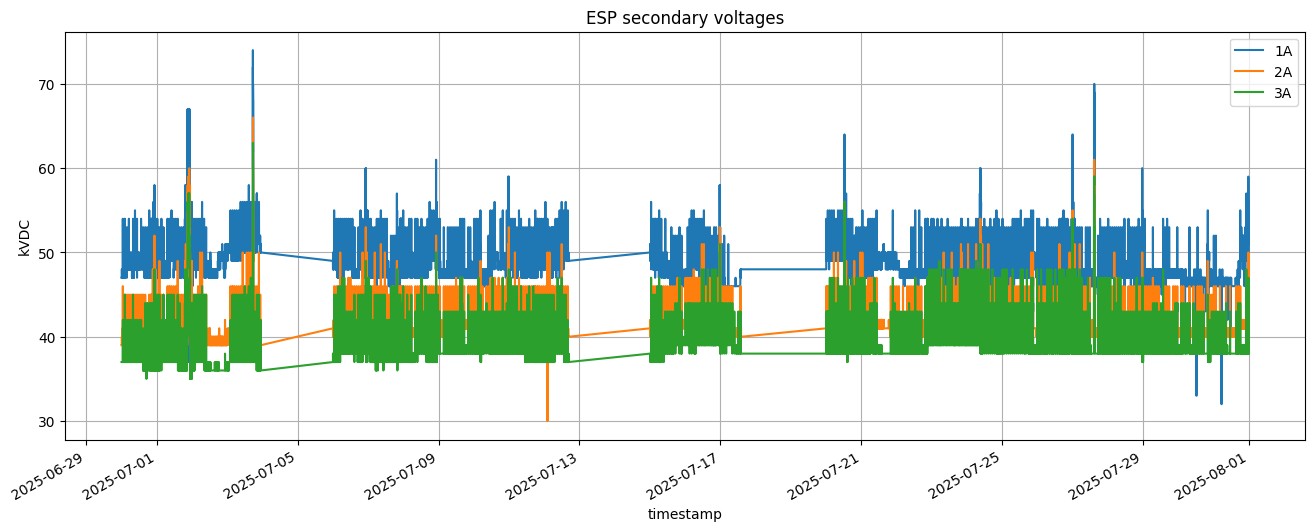

In [18]:
plt.figure(figsize=(16,6))

df['008A02289'].plot(label='1A')
df['008A02290'].plot(label='2A')
df['008A02291'].plot(label='3A')

plt.title('ESP secondary voltages')
plt.ylabel('kVDC')

plt.legend()
plt.grid(True)

plt.show()

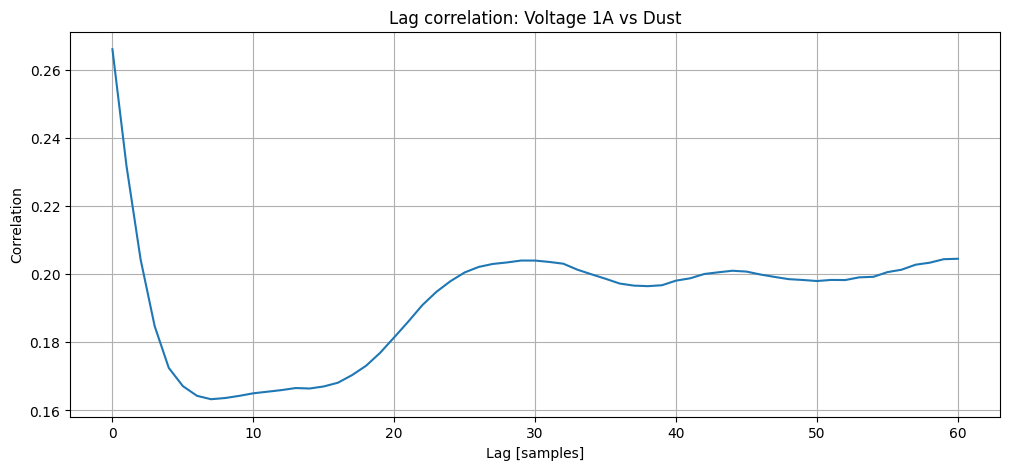

In [19]:
lag_corrs = []

for lag in range(0, 61):
    corr = df['008A02289'].shift(lag).corr(df['008A01345'])
    lag_corrs.append(corr)

plt.figure(figsize=(12,5))

plt.plot(range(0,61), lag_corrs)

plt.title('Lag correlation: Voltage 1A vs Dust')
plt.xlabel('Lag [samples]')
plt.ylabel('Correlation')

plt.grid(True)

plt.show()

In [20]:
model_cols = [
    '008A01345',  # pył target

    '008A00936',  # moc generatora

    '008A00719',
    '008A00727',  # ciśnienia

    '008A01350',  # O2

    '008A02289',
    '008A02290',
    '008A02291',  # napięcia wtórne

    '008A02267',
    '008A02268',
    '008A02269',  # prądy wtórne

    '008A02264',
    '008A02265',
    '008A02266',  # przeskoki
]

model_df = df[model_cols].copy()

print(model_df.shape)

model_df.head()

(217781, 14)


,008A01345,008A00936,008A00719,008A00727,008A01350,008A02289,008A02290,008A02291,008A02267,008A02268,008A02269,008A02264,008A02265,008A02266
timestamp,,,,,,,,,,,,,,
2025-06-30 00:00:00,11.0,32.500000,-0.63,-0.55,8.4,47.0,39.0,37.0,296.0,306.0,304.0,0.0,0.0,0.0
2025-06-30 00:00:10,11.0,31.700001,-0.63,-0.55,8.4,47.0,39.0,37.0,296.0,306.0,301.0,0.0,0.0,0.0
2025-06-30 00:00:20,11.0,32.000000,-0.63,-0.55,8.2,47.0,39.0,37.0,296.0,306.0,304.0,0.0,0.0,0.0
2025-06-30 00:00:30,11.0,31.799999,-0.63,-0.55,8.2,47.0,39.0,37.0,294.0,301.0,304.0,0.0,0.0,0.0
2025-06-30 00:00:40,9.0,32.400002,-0.63,-0.54,8.2,47.0,39.0,37.0,296.0,301.0,304.0,0.0,0.0,0.0


In [21]:
lag_features = [
    '008A02289',  # UWT 1A
    '008A02290',
    '008A02291',
]

for col in lag_features:

    model_df[f'{col}_lag_1m'] = model_df[col].shift(6)

    model_df[f'{col}_lag_5m'] = model_df[col].shift(30)

In [22]:
rolling_features = [
    '008A01345',
    '008A02289',
]

for col in rolling_features:

    model_df[f'{col}_rollmean_5m'] = (
        model_df[col]
        .rolling(30)
        .mean()
    )

In [23]:
model_df.head(40)

,008A01345,008A00936,008A00719,008A00727,008A01350,008A02289,008A02290,008A02291,008A02267,008A02268,...,008A02265,008A02266,008A02289_lag_1m,008A02289_lag_5m,008A02290_lag_1m,008A02290_lag_5m,008A02291_lag_1m,008A02291_lag_5m,008A01345_rollmean_5m,008A02289_rollmean_5m
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-06-30 00:00:00,11.0,32.500000,-0.63,-0.55,8.4,47.0,39.0,37.0,296.0,306.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 00:00:10,11.0,31.700001,-0.63,-0.55,8.4,47.0,39.0,37.0,296.0,306.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 00:00:20,11.0,32.000000,-0.63,-0.55,8.2,47.0,39.0,37.0,296.0,306.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 00:00:30,11.0,31.799999,-0.63,-0.55,8.2,47.0,39.0,37.0,294.0,301.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 00:00:40,9.0,32.400002,-0.63,-0.54,8.2,47.0,39.0,37.0,296.0,301.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 00:00:50,9.0,31.900000,-0.63,-0.55,8.2,47.0,39.0,37.0,296.0,306.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 00:01:00,9.0,31.900000,-0.63,-0.55,8.4,47.0,39.0,37.0,296.0,306.0,...,0.0,0.0,47.0,NaN,39.0,NaN,37.0,NaN,NaN,NaN
2025-06-30 00:01:10,9.0,31.500000,-0.63,-0.55,8.3,47.0,39.0,37.0,294.0,306.0,...,0.0,0.0,47.0,NaN,39.0,NaN,37.0,NaN,NaN,NaN
2025-06-30 00:01:20,9.0,32.500000,-0.63,-0.54,8.3,47.0,39.0,37.0,294.0,306.0,...,0.0,0.0,47.0,NaN,39.0,NaN,37.0,NaN,NaN,NaN


In [24]:
model_df = model_df.dropna()

print(model_df.shape)

(217751, 22)


In [25]:
target_col = '008A01345'

X = model_df.drop(columns=[target_col])

y = model_df[target_col]

print(X.shape)
print(y.shape)

(217751, 21)
(217751,)


In [26]:
split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(X_train.shape)
print(X_test.shape)

(174200, 21)
(43551, 21)


In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [28]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [29]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")

MAE: 1.34
R2: 0.660


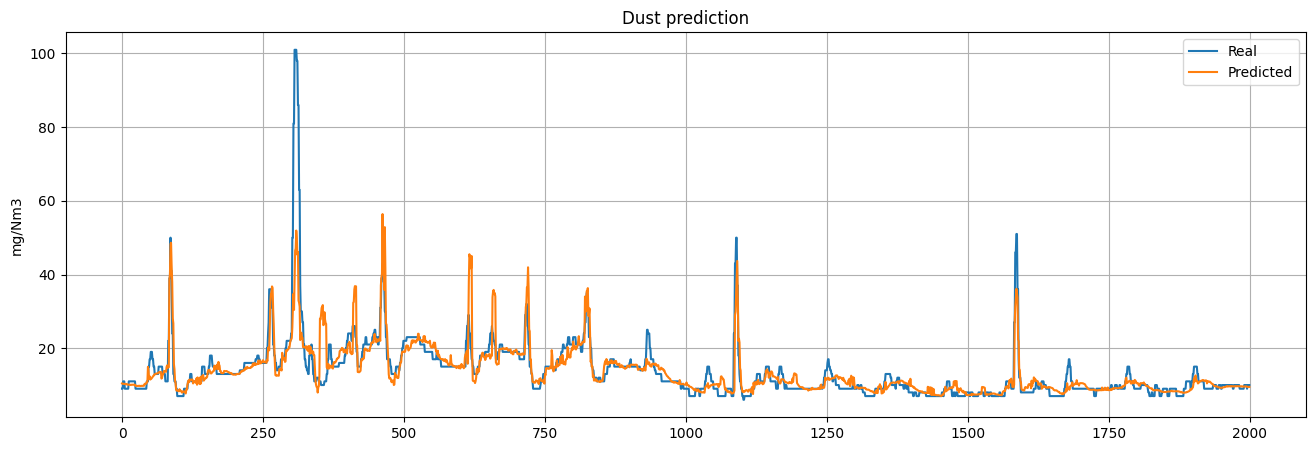

In [30]:
plt.figure(figsize=(16,5))

plt.plot(y_test.values[:2000], label='Real')
plt.plot(y_pred[:2000], label='Predicted')

plt.title('Dust prediction')
plt.ylabel('mg/Nm3')

plt.legend()
plt.grid(True)

plt.show()

In [31]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

importance = importance.sort_values(
    by='importance',
    ascending=False
)

importance.head(20)

,feature,importance
19,008A01345_rollmean_5m,0.245971
6,008A02291,0.161455
9,008A02269,0.136299
17,008A02291_lag_1m,0.090125
15,008A02290_lag_1m,0.078458
8,008A02268,0.048440
10,008A02264,0.030898
11,008A02265,0.026210
1,008A00719,0.026059
2,008A00727,0.024130


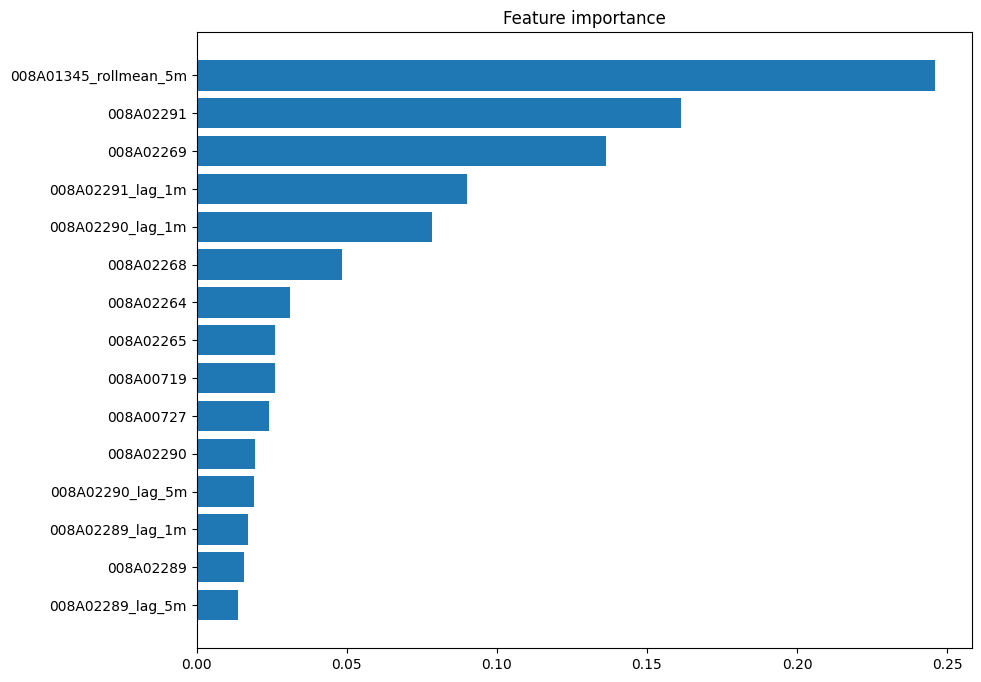

In [32]:
plt.figure(figsize=(10,8))

plt.barh(
    importance['feature'][:15][::-1],
    importance['importance'][:15][::-1]
)

plt.title('Feature importance')

plt.show()